In [1]:
!pip install anndata==0.8.0

In [3]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.colors
from sklearn.manifold import TSNE
import pickle
import matplotlib.colors as mcolors
import itertools
import numpy as np

In [3]:
with open('parent_dict.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [4]:
fn = 'Active_SAM_joined/SAM_DR_ncbi_NN_geneexp_11202025.h5ad'

In [5]:
sam=SAM()
sam.load_data(fn)

In [6]:
sam.adata.obs[sam.adata.obs['neurotransmitter_v2'] == 'unclear']['ss_subclass_nounlabeled_nmm_v3_nn'].value_counts()

dr_9                              2207
dr_33                              256
010 IT AON-TT-DP Glut                0
dr_13                                0
dr_11                                0
                                  ... 
133 PVH-SO-PVa Otp Glut              0
132 AHN-RCH-LHA Otp Fezf1 Glut       0
131 LHA-AHN-PVH Otp Trh Glut         0
129 VMH Nr5a1 Glut                   0
xt_dr_1                              0
Name: ss_subclass_nounlabeled_nmm_v3_nn, Length: 79, dtype: int64

In [27]:
Xtsne = TSNE(n_components=2, metric = 'cosine').fit_transform(sam.adata.obsm['X_pca'])

/scratch/miniconda/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/scratch/miniconda/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,
/scratch/miniconda/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:827: FutureWarning: 'square_distances' has been introduced in 0.24 to help phase out legacy squaring behavior. The 'legacy' setting will be removed in 1.1 (renaming of 0.26), and the default setting will be changed to True. In 1.3, 'square_distances' will be removed altogether, and distances will be squared by default. Set 'square_distances'=True to silence this warning.
  FutureWarning,


In [28]:
sam.adata.obsm['X_tsne'] = Xtsne

In [29]:
sam.save_anndata(fn)

In [7]:
with open('CT_color_mapping_06262026.pkl', 'rb') as f:
    CT_color_mapping = pickle.load(f)

In [8]:
region_mapping = {'ARH':'orange',
                 'VMH': 'maroon',
                 'PM': 'salmon',
                 'PVH':'rosybrown',
                 'DMH':'red',
                 'ZI':'saddlebrown',
                 'POA':'lavender',
                 'PH':'lightgreen',
                 'AHN':'blue',
                 'MM':'pink',
                 'MnPO':'teal',
                 'STN':'lime',
                 'LH':'purple',
                 'BST':'green',
                 'SCH':'lightpink',
                 'MS':'olive',
                 'NAC':'lightblue',
                 'MEA':'brown',
                 'Outside hypothalamus':'black',
                 'Unknown':'lightgrey'}

In [14]:
nt_mapping = {'Gaba-Chol':'#73E785',
             'Chol':'#73E785',
             'Glut-Chol':'#73E785',
             'Glut-Gaba-Dopa':'#FCF04B',
             'Gaba-Dopa':'#FCF04B',
             'Glut-Dopa':'#FCF04B',
             'Gaba-Dopa-Chol':'#FCF04B',
             'Dopa':'#FCF04B',
             'Gly':'#820E57',
             'Glut-Gly':'#820E57',
             'Glut-Gaba-Gly':'#820E57',
             'Hist':'#FF7621',
             'Gaba':'#FF3358',
             'Glut':'#2B93DF',
             'Glut-Gaba':'#0A9964',
             'Gaba-Gly':'#820E57',
             'Gaba-Hist':'#FF7621',
             'Nora':'#03EDFF',
             'Gaba-Sert':'#4f2e91ff',
             'Glut-Sert':'#4f2e91ff',
              '"Glut-Sert"':'#4f2e91ff',
             'Glut-Gaba-Sert':'#4f2e91ff',
             'Gaba-Dopa-Sert':'#4f2e91ff',
             'Glut-Gaba-Sert-Hist':'#4f2e91ff',
             'unclear':'lightgrey',
             'Sert':'#4f2e91ff',
             'Glut-Gaba-Hist':'#FF7621'}

In [10]:
CT_color_mapping['Unlabeled'] = 'grey'

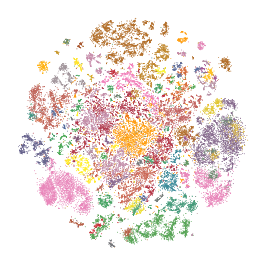

In [12]:
#Figure 1B 02272025
plt.rcParams["figure.figsize"] = (3.8,3.8)
g = sc.pl.tsne(sam.adata, color = 'ss_subclass_nounlabeled_nmm_v3_nn', s = 2, palette = CT_color_mapping, frameon=False, return_fig=True, legend_loc = None)
plt.title(None)
plt.tight_layout()
#plt.legend(ncol=1, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
g.patch.set_facecolor('black')
g.patch.set_alpha(0)
g.savefig('Figures/Figures_07032026/DR_sss_subclass_v3_07012026.png', bbox_inches='tight', dpi = 300)
plt.show()

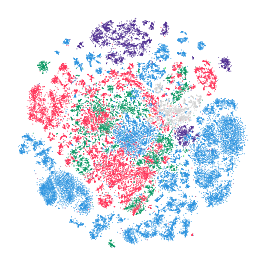

In [15]:
plt.rcParams["figure.figsize"] = (3.8,3.8)
g = sc.pl.tsne(sam.adata, color = 'neurotransmitter_v2', s = 2,palette = nt_mapping , frameon=False, return_fig=True,legend_loc=None)
plt.title(None)
plt.tight_layout()
#plt.legend(ncol=1, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
#plt.legend([])
g.patch.set_facecolor('black')
g.patch.set_alpha(0)
g.savefig('Figures/Figures_07032026/DR_ss_subclass_v3_neurotransmitterv2_07012026.png', bbox_inches='tight', dpi = 600)
plt.show()

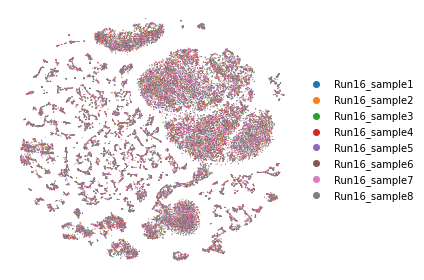

In [9]:
#Figure 1B 02272025
plt.rcParams["figure.figsize"] = (7,5)
g = sc.pl.tsne(sam.adata, color = 'key', s = 4, frameon=False, return_fig=True)
plt.title(None)
plt.tight_layout()
#plt.legend(ncol=1, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
g.patch.set_facecolor('black')
g.patch.set_alpha(0)
#g.savefig('Figures/Figures_01022026/MV_subclass_id_label_mapping_12262025.png', bbox_inches='tight', dpi = 600)
plt.show()

In [75]:
nt_color = [nt_mapping[i] for i in sam.adata.obs['neurotransmitter']]
nt_color_two = [nt_mapping[i] for i in sam_non_NT.obs['neurotransmitter']]

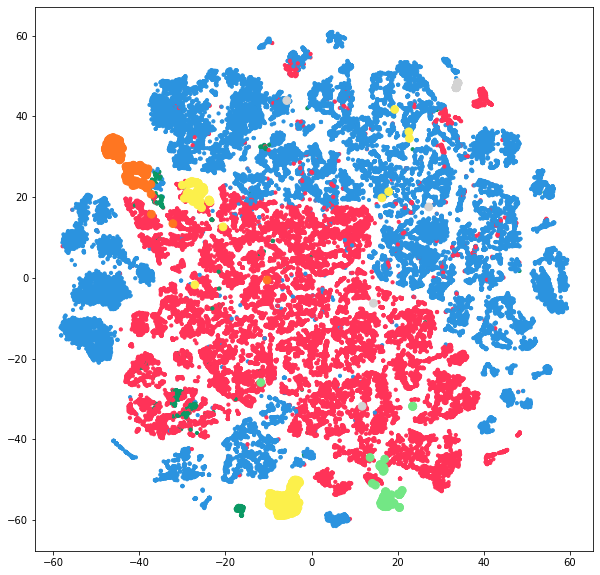

In [76]:
plt.scatter(sam.adata.obsm['X_tsne'][:,0],sam.adata.obsm['X_tsne'][:,1], c = nt_color,s=10)
plt.scatter(sam_non_NT.obsm['X_tsne'][:,0],sam_non_NT.obsm['X_tsne'][:,1], c = nt_color_two,s=60)

In [59]:
plotter = []
for item in sam.adata.obs['eq_subclass_nounlabeled_nmm']:
    if len(item) == 7 or len(item) == 8:
        if item[:5] == 'cj_ac':
            plotter.append(item)
        else:
            plotter.append('other')
    else:
        plotter.append('other')
sam.adata.obs['plotter'] = plotter

In [94]:
plotter = []
for item in sam.adata.obs['eq_subclass_nounlabeled_nmm']:
    if len(item) == 13:
        if item[:11] == 'cj_ac_xt_dr':
            plotter.append(item)
        else:
            plotter.append('other')
    else:
        plotter.append('other')
sam.adata.obs['plotter'] = plotter

In [95]:
sam.adata.obs['plotter'].unique()

array(['other', 'cj_ac_xt_dr_1', 'cj_ac_xt_dr_2'], dtype=object)

In [28]:
nt_mapping = {'Gaba-Chol':'#73E785',
             'Chol':'#73E785',
             'Glut-Gaba-Dopa':'#FCF04B',
             'Gaba-Dopa':'#FCF04B',
             'Glut-Dopa':'#FCF04B',
             'Gaba':'#FF3358',
             'Glut':'#2B93DF',
             'Glut-Gaba':'#0A9964',
             'Gaba-Gly':'#820E57',
             'Gaba-Hist':'#FF7621',
             'Nora':'#03EDFF',
             'Gaba-Sert':'#4f2e91ff',
             'Gaba-Dopa-Sert':'#4f2e91ff',
             'unclear':'lightgrey'}

In [61]:
cj_ac = {'other':'lightgrey', 'cj_ac_0':'#73E785', 'cj_ac_1':'#FCF04B', 'cj_ac_12':'#FF3358', 'cj_ac_8':'#2B93DF', 'cj_ac_10':'#0A9964',
       'cj_ac_6':'#820E57', 'cj_ac_5':'#FF7621', 'cj_ac_7':'#03EDFF', 'cj_ac_11':'#4f2e91ff'}

In [82]:
cj_ac_xt = {'other':'lightgrey', 'cj_ac_xt_1':'#73E685', 'cj_ac_xt_2':'#FCF04B'}

In [92]:
cj_xt_dr = {'other':'lightgrey', 'cj_xt_dr_1':'#73E685'}

In [96]:
cj_ac_xt_dr = {'other':'lightgrey','cj_ac_xt_dr_1':'#73E685','cj_ac_xt_dr_2':'#FCF04B'}

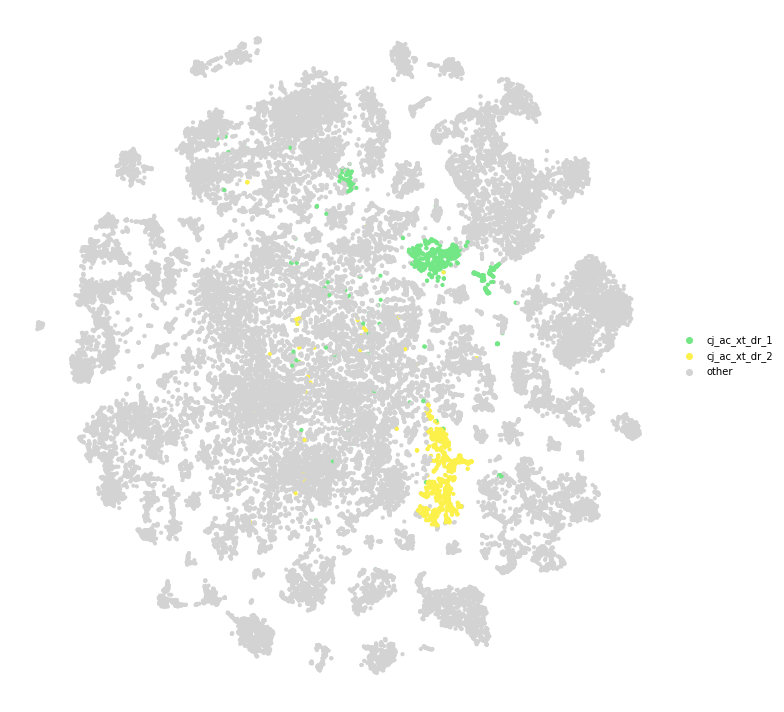

In [97]:
plt.rcParams["figure.figsize"] = (11,10)
g = sc.pl.tsne(sam.adata, color = 'plotter', s = 70,palette =cj_ac_xt_dr, frameon=False, return_fig=True)
plt.title(None)
plt.tight_layout()
plt.legend(ncol=1, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
#plt.legend([])
g.patch.set_facecolor('black')
g.patch.set_alpha(0)
g.savefig('Figures/Figures_02082025/DR_cj_ac_xt_nmm_tsne.png', bbox_inches='tight', dpi = 600)
plt.show()

In [292]:
sam.save_anndata(fn)

In [ ]:
import math

import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.cm import hsv


def generate_colormap(number_of_distinct_colors: int = 80):
    if number_of_distinct_colors == 0:
        number_of_distinct_colors = 80

    number_of_shades = 7
    number_of_distinct_colors_with_multiply_of_shades = int(math.ceil(number_of_distinct_colors / number_of_shades) * number_of_shades)

    # Create an array with uniformly drawn floats taken from <0, 1) partition
    linearly_distributed_nums = np.arange(number_of_distinct_colors_with_multiply_of_shades) / number_of_distinct_colors_with_multiply_of_shades

    # We are going to reorganise monotonically growing numbers in such way that there will be single array with saw-like pattern
    #     but each saw tooth is slightly higher than the one before
    # First divide linearly_distributed_nums into number_of_shades sub-arrays containing linearly distributed numbers
    arr_by_shade_rows = linearly_distributed_nums.reshape(number_of_shades, number_of_distinct_colors_with_multiply_of_shades // number_of_shades)

    # Transpose the above matrix (columns become rows) - as a result each row contains saw tooth with values slightly higher than row above
    arr_by_shade_columns = arr_by_shade_rows.T

    # Keep number of saw teeth for later
    number_of_partitions = arr_by_shade_columns.shape[0]

    # Flatten the above matrix - join each row into single array
    nums_distributed_like_rising_saw = arr_by_shade_columns.reshape(-1)

    # HSV colour map is cyclic (https://matplotlib.org/tutorials/colors/colormaps.html#cyclic), we'll use this property
    initial_cm = hsv(nums_distributed_like_rising_saw)

    lower_partitions_half = number_of_partitions // 2
    upper_partitions_half = number_of_partitions - lower_partitions_half

    # Modify lower half in such way that colours towards beginning of partition are darker
    # First colours are affected more, colours closer to the middle are affected less
    lower_half = lower_partitions_half * number_of_shades
    for i in range(3):
        initial_cm[0:lower_half, i] *= np.arange(0.2, 1, 0.8/lower_half)

    # Modify second half in such way that colours towards end of partition are less intense and brighter
    # Colours closer to the middle are affected less, colours closer to the end are affected more
    for i in range(3):
        for j in range(upper_partitions_half):
            modifier = np.ones(number_of_shades) - initial_cm[lower_half + j * number_of_shades: lower_half + (j + 1) * number_of_shades, i]
            modifier = j * modifier / upper_partitions_half
            initial_cm[lower_half + j * number_of_shades: lower_half + (j + 1) * number_of_shades, i] += modifier

    return ListedColormap(initial_cm)

In [20]:
fin = generate_colormap(117)

In [26]:
for item in fin:
    print(item)

TypeError: 'ListedColormap' object is not iterable